In [ ]:
pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [ ]:
pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import mlflow
import joblib
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from google.colab import drive
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, classification_report, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.utils import resample
from imblearn.under_sampling import RandomUnderSampler

# Configuration de la reproductibilité
SEED = 123
np.random.seed(SEED)

# Montage Google Drive et configuration MLflow
drive.mount('/content/drive')
CHEMIN_DRIVE_TRACKING = '/content/drive/MyDrive/Projet_ML2/MLFlow_Tracking'
mlflow.set_tracking_uri(f'file://{CHEMIN_DRIVE_TRACKING}')
mlflow.set_experiment('Pret_A_Depenser_Scoring')



Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///content/drive/MyDrive/Projet_ML2/MLFlow_Tracking/933425481062839022', creation_time=1776816395529, experiment_id='933425481062839022', last_update_time=1776816395529, lifecycle_stage='active', name='Pret_A_Depenser_Scoring', tags={}, trace_location=None, workspace='default'>

In [ ]:
# Chargement des données mergées par Polars
DATA_PATH = "/content/drive/MyDrive/Data/train_final.csv"

df = pd.read_csv(DATA_PATH)
print(f"Base chargée : {df.shape[0]} lignes et {df.shape[1]} variables.")

# Séparation Features / Target
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

# Nettoyage des noms de colonnes (suppression des caractères spéciaux)
import re
X = X.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

Base chargée : 307511 lignes et 444 variables.


In [ ]:
# Séparation 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y # Garde la même proportion de pour la variable cible
)

print(f"Taille du Train set : {X_train.shape}")
print(f"Taille du Test set : {X_test.shape}")

Taille du Train set : (246008, 442)
Taille du Test set : (61503, 442)


In [ ]:
# Conversion des colonnes de type 'object' en 'category'
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print("Conversion des colonnes catégorielles en type 'category' effectuée.")

Conversion des colonnes catégorielles en type 'category' effectuée.


In [ ]:
def custom_business_cost(y_true, y_pred_proba, threshold=0.5):
    """
    Calcule le coût financier théorique.
    FN (Défaut non détecté) : Coût 5
    FP (Refus injustifié) : Coût 1
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (5 * fn) + (1 * fp)

def lgb_business_metric(y_true, y_pred):
    cost = custom_business_cost(y_true, y_pred)
    return 'business_cost', cost, False

# Grille de seuils pour l'optimisation métier
thresholds = np.linspace(0.01, 0.99, 100)

In [ ]:
from sklearn.metrics import roc_curve

def plot_model_performance(y_true, y_proba, thresholds, model_name):
    """
    Affiche la matrice de confusion (au seuil optimal), la courbe ROC
    et la courbe d'optimisation du coût métier.
    """
    # Calcul des coûts pour chaque seuil
    costs = [custom_business_cost(y_true, y_proba, threshold=t) for t in thresholds]
    min_cost = min(costs)
    opt_threshold = thresholds[costs.index(min_cost)]

    # Prédiction avec le seuil optimal
    y_pred = (y_proba >= opt_threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Performance - {model_name}', fontsize=16)

    # 1. Matrice de Confusion
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix (Threshold: {opt_threshold:.2f})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # 2. Courbe ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_score = roc_auc_score(y_true, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc_score:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")

    # 3. Optimisation du Coût Métier
    axes[2].plot(thresholds, costs, color='green')
    axes[2].axvline(opt_threshold, color='red', linestyle='--', label=f'Opt. Threshold: {opt_threshold:.2f}')
    axes[2].set_title('Business Cost Optimization')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Total Cost')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return opt_threshold, min_cost

# 1. Préparation des Données et Pipeline
Sélection des variables significatives et définition du preprocessor pour les modèles de base.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Liste des 20 variables significatives les plus significative identifiées lors de l'EDA
selected_features = [
    'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'INST_DPD_LATE_MEAN', 'AMT_CREDIT', 'INST_AMT_PAYMENT_SUM', 'AMT_ANNUITY',
    'DAYS_EMPLOYED', 'POS_CNT_INSTALMENT_FUTURE_MEAN', 'AMT_GOODS_PRICE',
    'INST_DBD_MEAN', 'BURO_DAYS_CREDIT_MAX', 'PREV_CNT_PAYMENT_MEAN',
    'BURO_DAYS_CREDIT_ENDDATE_MAX', 'OCCUPATION_TYPE', 'DAYS_ID_PUBLISH',
    'CC_CNT_DRAWINGS_ATM_CURRENT_MEAN', 'OWN_CAR_AGE', 'CODE_GENDER'
]

# Filtrage des données
existing_features = [c for c in selected_features if c in X_train.columns]
X_train_sub = X_train[existing_features]
X_test_sub = X_test[existing_features]

# Identification des types de colonnes pour le preprocessor
numeric_features = X_train_sub.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_sub.select_dtypes(include=['object', 'category']).columns.tolist()

# --- Definition ddu processing ---

# Numérique
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Catégoriel (OneHot encoding)
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='undefined')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline de preprocessing global
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', onehot_transformer, categorical_features)
])



### 2. Modèle Dummy (Baseline Zéro)
Ce modèle sert à vérifier si nos futurs modèles font mieux que le hasard ou la classe majoritaire.

In [ ]:
with mlflow.start_run(run_name='Dummy_Classifier_Baseline'):
    dummy_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DummyClassifier(strategy='stratified', random_state=SEED))
    ])
    dummy_pipe.fit(X_train_sub, y_train)

    y_proba_dummy = dummy_pipe.predict_proba(X_test_sub)[:, 1]
    auc_dummy = roc_auc_score(y_test, y_proba_dummy)

    dummy_costs = [custom_business_cost(y_test, y_proba_dummy, threshold=t) for t in thresholds]
    min_cost_dummy = min(dummy_costs)

    print(f'Dummy AUC: {auc_dummy:.4f}')
    print(f'Dummy Business Cost: {min_cost_dummy}')

    mlflow.log_metric('AUC_ROC', auc_dummy)
    mlflow.log_metric('Business_Cost_Min', min_cost_dummy)

Dummy AUC: 0.4988
Dummy Business Cost: 27426


Visualisation Dummy Classifier :


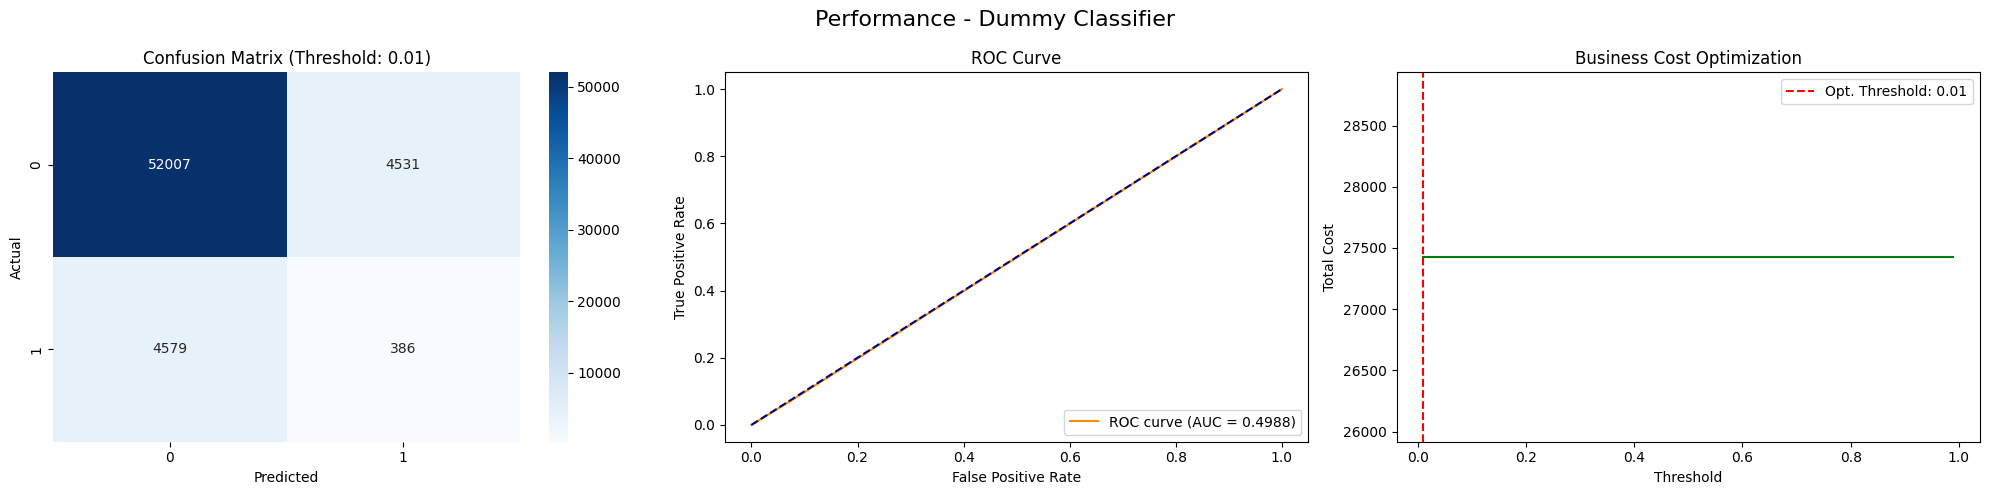

In [ ]:
print("Visualisation Dummy Classifier :")
_, _ = plot_model_performance(y_test, y_proba_dummy, thresholds, 'Dummy Classifier')

### 3. Régression Logistique (Baseline Simple)
Premier vrai modèle statistique pour comparer avec LightGBM.

In [ ]:
with mlflow.start_run(run_name='Logistic_Regression_Baseline'):
    log_reg_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
    ])

    log_reg_pipe.fit(X_train_sub, y_train)
    y_proba_log = log_reg_pipe.predict_proba(X_test_sub)[:, 1]
    auc_log = roc_auc_score(y_test, y_proba_log)

    log_costs = [custom_business_cost(y_test, y_proba_log, threshold=t) for t in thresholds]
    min_cost_log = min(log_costs)
    opt_threshold_log = thresholds[log_costs.index(min_cost_log)]

    print(f'--- Résultats Régression Logistique ---')
    print(f'AUC-ROC : {auc_log:.4f}')
    print(f'Coût Métier Minimum : {min_cost_log}')

    mlflow.log_metric('AUC_ROC', auc_log)
    mlflow.log_metric('Business_Cost_Min', min_cost_log)
    mlflow.log_metric('Optimal_Threshold', opt_threshold_log)

--- Résultats Régression Logistique ---
AUC-ROC : 0.7427
Coût Métier Minimum : 21763


Visualisation Logistic Regression :


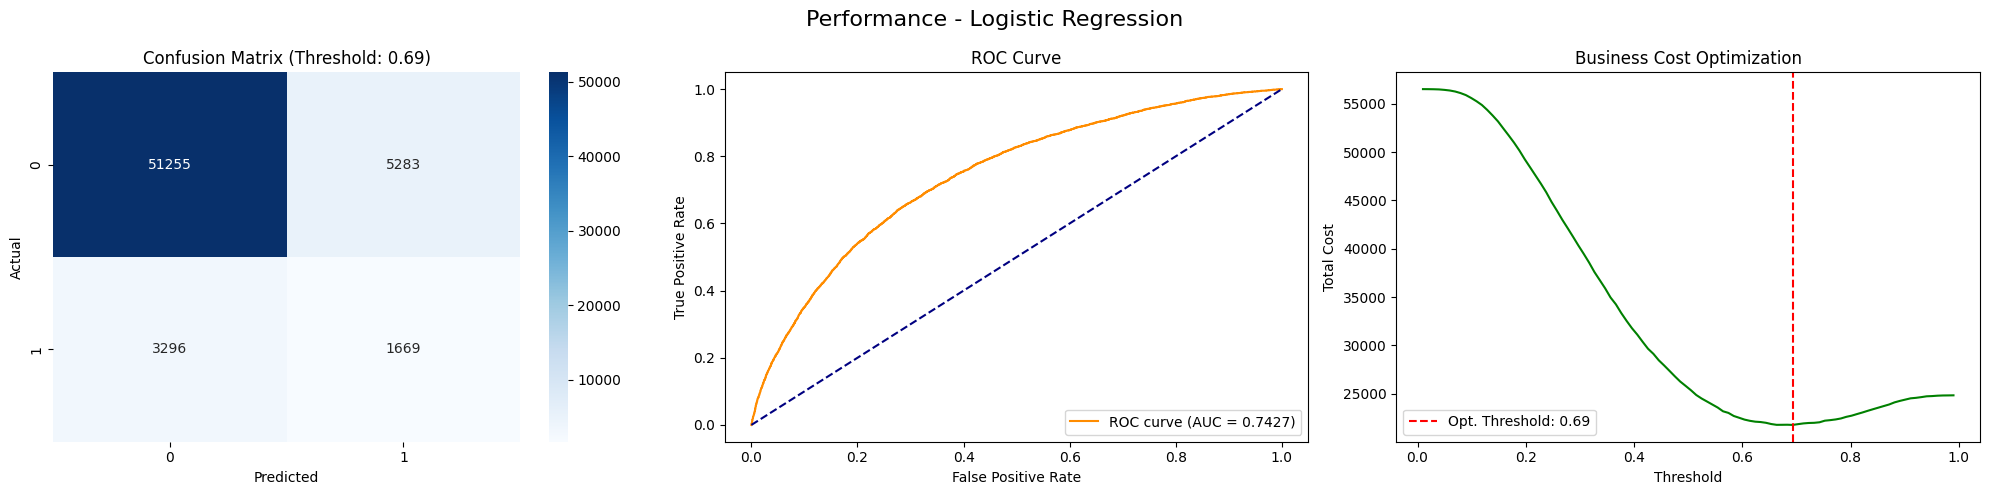

In [ ]:
print("Visualisation Logistic Regression :")
_, _ = plot_model_performance(y_test, y_proba_log, thresholds, 'Logistic Regression')

### 4. Modèle K-Nearest Neighbors (KNN)
Optimisation des hyperparamètres via RandomizedSearchCV sur le sous-ensemble de 20 variables.

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

print("Optimisation du KNN sur un échantillon réduit pour gagner du temps...")

# On entraine le KNN sur un échnatillon réduit du train pour résuire le temps d'entrainement qui exploserait sinon.
X_train_knn, y_train_knn = resample(
    X_train_sub, y_train,
    n_samples=50000,
    replace=False,
    stratify=y_train,
    random_state=SEED
)

# Paramètres à tester
knn_params = {
    'classifier__n_neighbors': [20, 50, 100],
    'classifier__weights': ['uniform', 'distance']
}

# Pipeline KNN
knn_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_jobs=-1))
])

# Recherche d'hyperparamètres
knn_search = RandomizedSearchCV(
    knn_pipe,
    knn_params,
    n_iter=4,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    verbose=1,
    random_state=SEED
)

with mlflow.start_run(run_name="KNN_Optimization_Subsampled"):
    print("Démarrage de la recherche (échantillon de 10k)...")
    knn_search.fit(X_train_knn, y_train_knn)

    best_knn = knn_search.best_estimator_
    y_proba_knn = best_knn.predict_proba(X_test_sub)[:, 1]
    auc_knn = roc_auc_score(y_test, y_proba_knn)

    # Optimisation du seuil
    knn_costs = [custom_business_cost(y_test, y_proba_knn, threshold=t) for t in thresholds]
    min_cost_knn = min(knn_costs)
    opt_threshold_knn = thresholds[knn_costs.index(min_cost_knn)]

    print(f"--- Résultats KNN (Échantillonné) ---")
    print(f"Meilleurs paramètres : {knn_search.best_params_}")
    print(f"AUC-ROC : {auc_knn:.4f}")
    print(f"Seuil Optimal : {opt_threshold_knn:.3f}")
    print(f"Coût Métier Minimum : {min_cost_knn}")

    mlflow.log_params(knn_search.best_params_)
    mlflow.log_metric("AUC_ROC", auc_knn)
    mlflow.log_metric("Business_Cost_Min", min_cost_knn)
    mlflow.log_metric("Optimal_Threshold", opt_threshold_knn)


Optimisation du KNN sur un échantillon réduit pour gagner du temps...
Démarrage de la recherche (échantillon de 10k)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
--- Résultats KNN (Échantillonné) ---
Meilleurs paramètres : {'classifier__weights': 'uniform', 'classifier__n_neighbors': 100}
AUC-ROC : 0.7154
Seuil Optimal : 0.158
Coût Métier Minimum : 22282


Visualisation KNN :


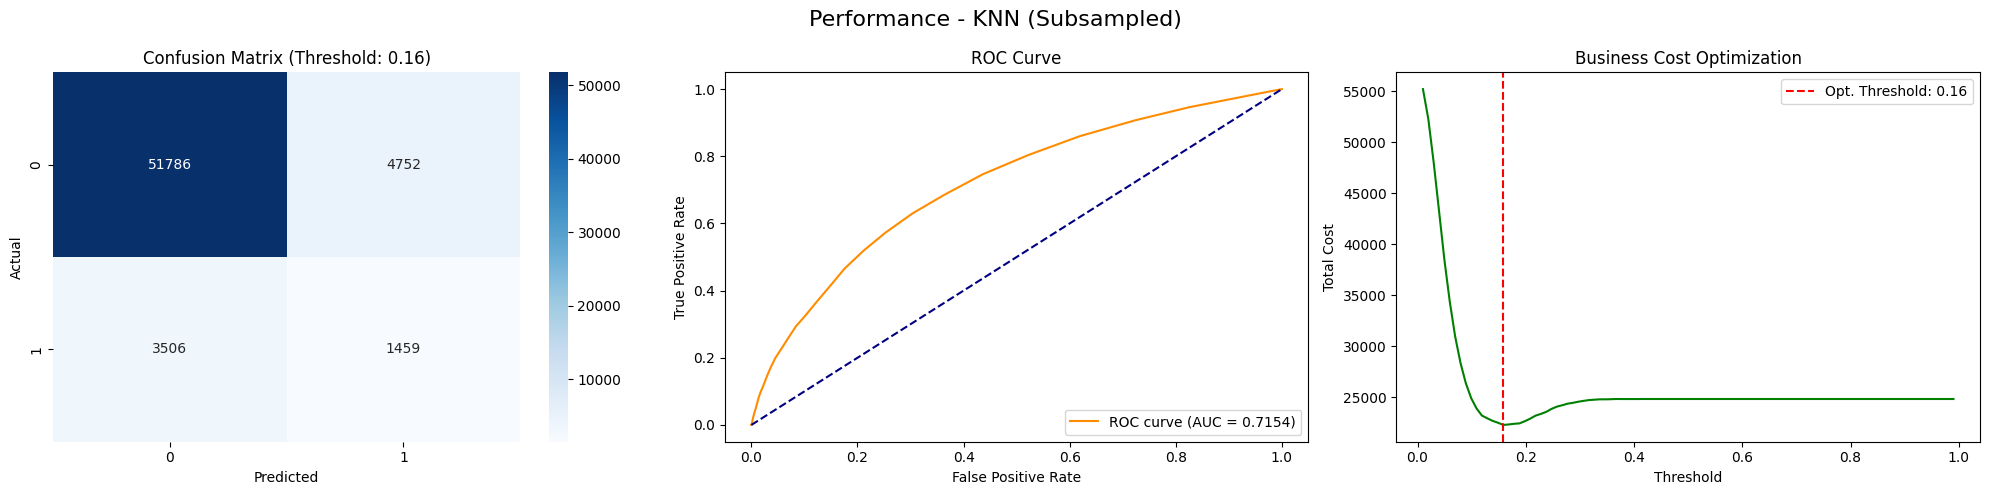

In [ ]:
print("Visualisation KNN :")
_, _ = plot_model_performance(y_test, y_proba_knn, thresholds, 'KNN (Subsampled)')

### 5. Simple Decision Tree (Baseline)
Avant de passer aux ensembles, nous testons un arbre de décision unique pour évaluer la performance d'un modèle non-linéaire simple.

In [ ]:

from sklearn.tree import DecisionTreeClassifier

with mlflow.start_run(run_name="DecisionTree_Baseline"):
    dt_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=SEED))
    ])

    dt_pipe.fit(X_train_sub, y_train)

    y_proba_dt = dt_pipe.predict_proba(X_test_sub)[:, 1]
    auc_dt = roc_auc_score(y_test, y_proba_dt)

    # Optimisation du seuil
    dt_costs = [custom_business_cost(y_test, y_proba_dt, threshold=t) for t in thresholds]
    min_cost_dt = min(dt_costs)
    opt_threshold_dt = thresholds[dt_costs.index(min_cost_dt)]

    print(f"--- Résultats Simple Decision Tree ---")
    print(f"AUC-ROC : {auc_dt:.4f}")
    print(f"Seuil Optimal : {opt_threshold_dt:.3f}")
    print(f"Coût Métier Minimum : {min_cost_dt}")

    mlflow.log_metric("AUC_ROC", auc_dt)
    mlflow.log_metric("Business_Cost_Min", min_cost_dt)
    mlflow.log_metric("Optimal_Threshold", opt_threshold_dt)


--- Résultats Simple Decision Tree ---
AUC-ROC : 0.7012
Seuil Optimal : 0.752
Coût Métier Minimum : 22473


Visualisation Decision Tree :


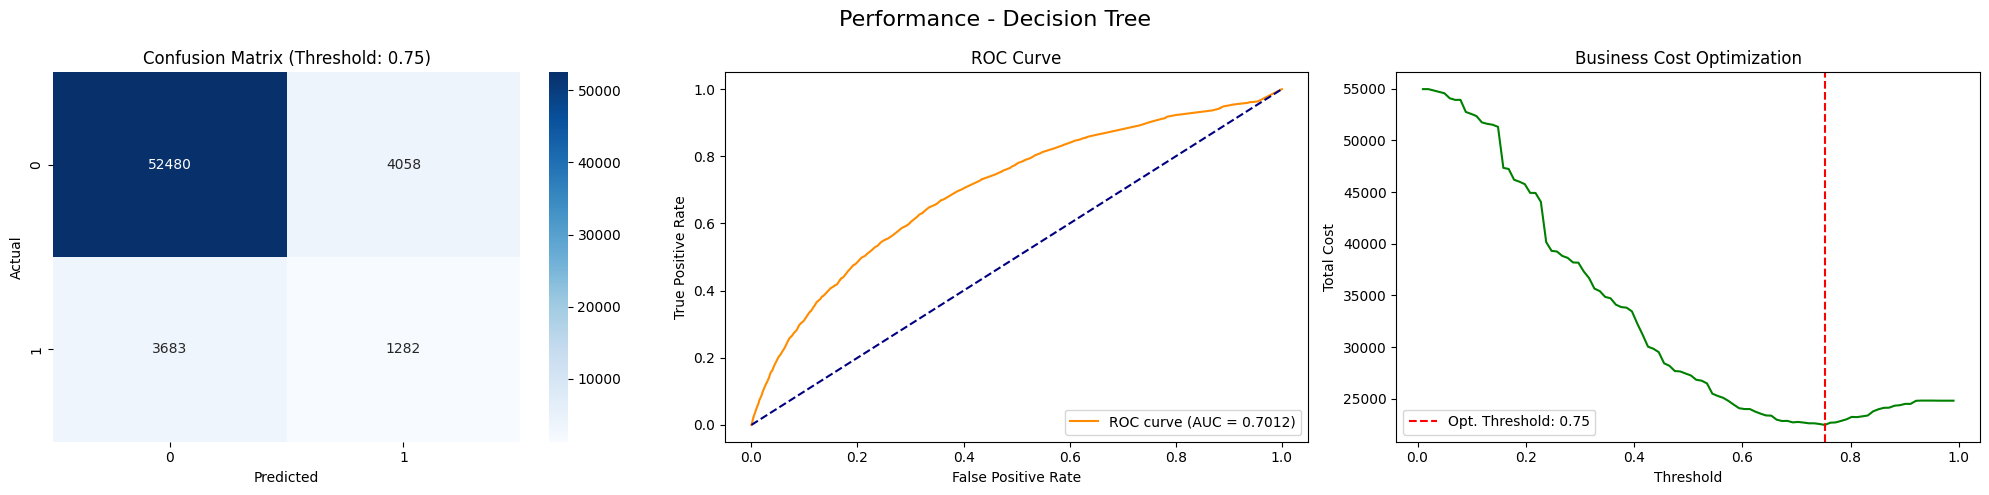

In [ ]:
print("Visualisation Decision Tree :")
_, _ = plot_model_performance(y_test, y_proba_dt, thresholds, 'Decision Tree')

### 6. Random Forest (Modèle Complexe - 400+ variables)
Comme suggéré, nous entraînons maintenant un Random Forest sur l'ensemble des données pour comparer sa puissance à celle de LightGBM.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample
import numpy as np

with mlflow.start_run(run_name="RandomForest_Full_Optimized"):
    # 1. Nettoyage des données
    X_train_rf_full = X_train.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test_rf_full = X_test.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)

    # 2. Sous-échantillonnage pour l'optimisation comme pour KNN, afin d'éviter le temps d'entainement qui explose.
    X_train_samp, y_train_samp = resample(
        X_train_rf_full, y_train,
        n_samples=50000,
        stratify=y_train,
        random_state=SEED
    )

    # 3. Grille de recherche
    rf_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_leaf': [50, 100]
    }

    rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)

    print(f"Recherche des meilleurs paramètres RF sur échantillon")
    rf_search = RandomizedSearchCV(
        rf_base, rf_grid, n_iter=5, cv=3, scoring='roc_auc', verbose=1, random_state=SEED
    )
    rf_search.fit(X_train_samp, y_train_samp)
    best_rf = rf_search.best_estimator_

    # 4. Entraînement final sur tout le train set
    print("Entraînement final du meilleur modèle sur le dataset complet...")
    best_rf.fit(X_train_rf_full, y_train)

    # 5. Évaluation et Seuil
    y_proba_rf = best_rf.predict_proba(X_test_rf_full)[:, 1]
    auc_rf = roc_auc_score(y_test, y_proba_rf)

    rf_costs = [custom_business_cost(y_test, y_proba_rf, threshold=t) for t in thresholds]
    min_cost_rf = min(rf_costs)

    print(f"RF AUC: {auc_rf:.4f}")
    print(f"RF Business Cost: {min_cost_rf}")

    mlflow.log_params(rf_search.best_params_)
    mlflow.log_metric("AUC_ROC", auc_rf)
    mlflow.log_metric("Business_Cost_Min", min_cost_rf)

Recherche des meilleurs paramètres RF sur échantillon
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Entraînement final du meilleur modèle sur le dataset complet...
RF AUC: 0.7563
RF Business Cost: 21181


Visualisation Random Forest :


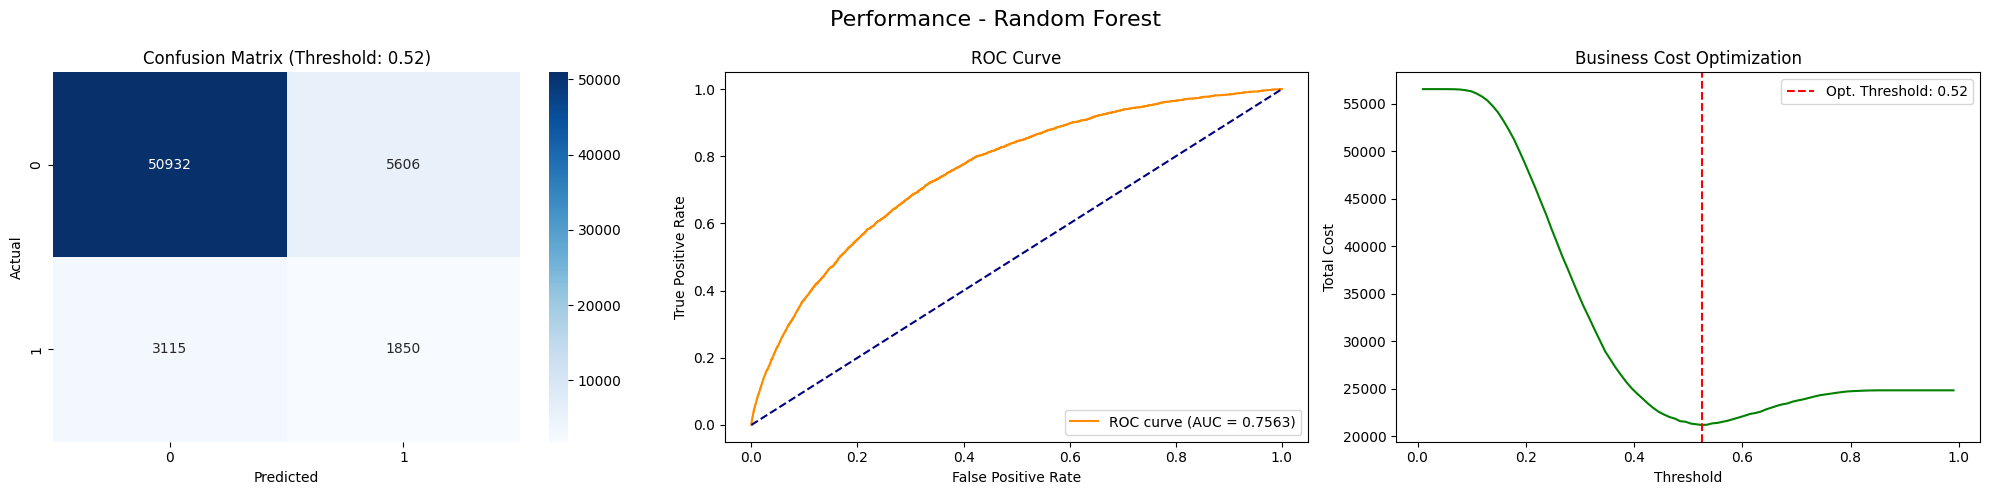

In [ ]:
print("Visualisation Random Forest :")
_, _ = plot_model_performance(y_test, y_proba_rf, thresholds, 'Random Forest')

### 7. Modèle XGBoost
Nous testons XGBoost sur l'ensemble des données numériques (comme pour le Random Forest).

In [ ]:
with mlflow.start_run(run_name='XGBoost_Full_Optimized'):
    # 1. Préparation et échantillonnage
    X_train_xgb_full = X_train.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test_xgb_full = X_test.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train_samp, y_train_samp = resample(
        X_train_xgb_full, y_train,
        n_samples=50000,
        stratify=y_train,
        random_state=SEED
    )

    # 2. Recherche d'hyperparamètres
    xgb_grid = {
        'n_estimators': [100, 200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1]
    }

    xgb_base = xgb.XGBClassifier(
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
        random_state=SEED,
        tree_method='hist',
        n_jobs=-1
    )

    print("Recherche des meilleurs paramètres XGBoost...")
    xgb_search = RandomizedSearchCV(
        xgb_base, xgb_grid, n_iter=4, cv=3, scoring='roc_auc', verbose=1, random_state=SEED
    )
    xgb_search.fit(X_train_samp, y_train_samp)
    xgb_model = xgb_search.best_estimator_

    # 3. Entraînement final
    print("Entraînement final XGBoost sur dataset complet...")
    xgb_model.fit(X_train_xgb_full, y_train)
    y_proba_xgb = xgb_model.predict_proba(X_test_xgb_full)[:, 1]

    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    xgb_costs = [custom_business_cost(y_test, y_proba_xgb, threshold=t) for t in thresholds]
    min_cost_xgb = min(xgb_costs)

    print(f'XGBoost AUC: {auc_xgb:.4f}')
    print(f'XGBoost Business Cost: {min_cost_xgb}')

    mlflow.log_params(xgb_search.best_params_)
    mlflow.log_metric('AUC_ROC', auc_xgb)
    mlflow.log_metric('Business_Cost_Min', min_cost_xgb)

Recherche des meilleurs paramètres XGBoost...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Entraînement final XGBoost sur dataset complet...
XGBoost AUC: 0.7734
XGBoost Business Cost: 20386


Visualisation XGBoost :


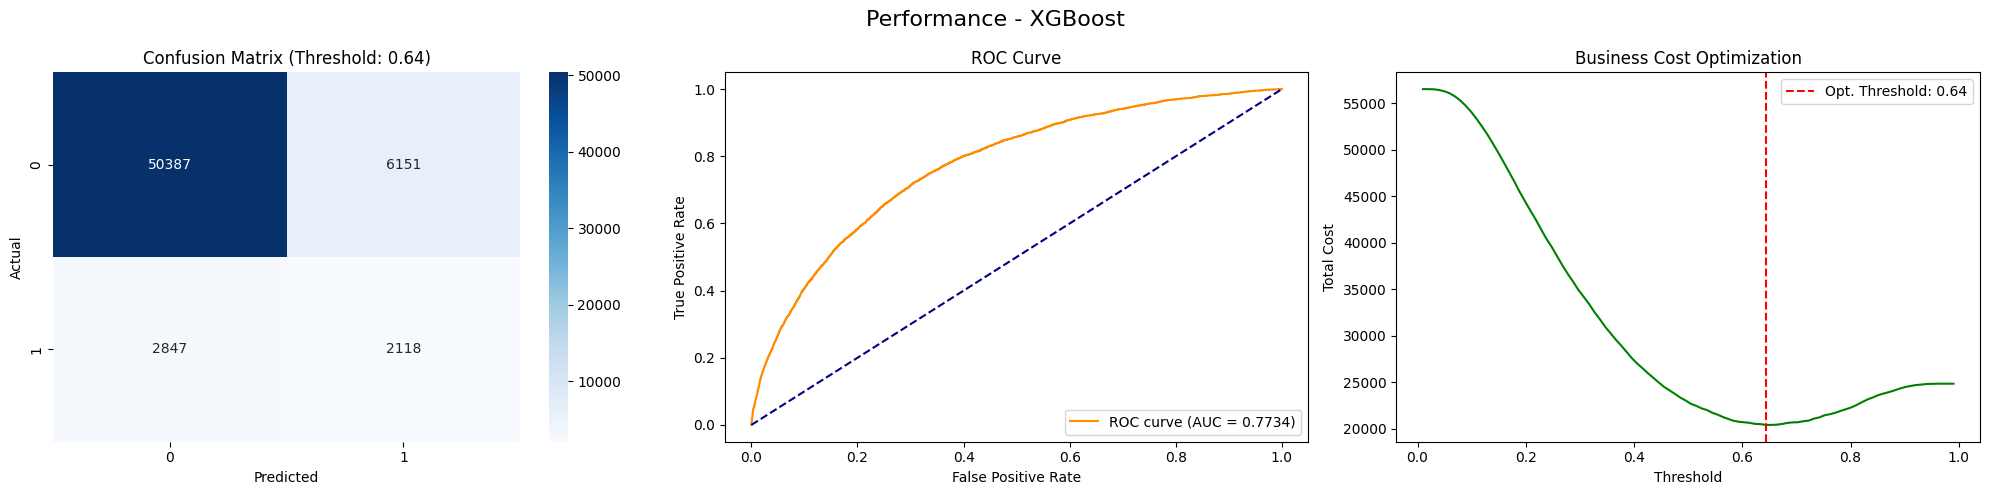

In [ ]:
print("Visualisation XGBoost :")
_, _ = plot_model_performance(y_test, y_proba_xgb, thresholds, 'XGBoost')

### 8. Modèle CatBoost
CatBoost peut gérer directement les colonnes catégorielles (`object` ou `category`).

In [ ]:
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

with mlflow.start_run(run_name='CatBoost_Full_Dataset'):
    # 1. Recherche d'hyperparamètres sur échantillon
    X_train_samp, y_train_samp = resample(
        X_train_cb, y_train,
        n_samples=50000,
        stratify=y_train,
        random_state=SEED
    )

    cb_grid = {'iterations': [100, 200], 'depth': [4, 6]}
    cb_base = CatBoostClassifier(auto_class_weights='Balanced', random_seed=SEED, verbose=False)

    print("Recherche des meilleurs paramètres CatBoost...")
    cb_search = RandomizedSearchCV(cb_base, cb_grid, n_iter=3, cv=2, scoring='roc_auc', random_state=SEED)
    cb_search.fit(X_train_samp, y_train_samp, cat_features=cat_features)
    best_cb = cb_search.best_estimator_

    # 2. Entraînement final
    print("Entraînement final CatBoost sur dataset complet...")
    best_cb.fit(X_train_cb, y_train, cat_features=cat_features)
    y_proba_cb = best_cb.predict_proba(X_test_cb)[:, 1]

    auc_cb = roc_auc_score(y_test, y_proba_cb)
    cb_costs = [custom_business_cost(y_test, y_proba_cb, threshold=t) for t in thresholds]
    min_cost_cb = min(cb_costs)

    print(f'CatBoost AUC: {auc_cb:.4f}')
    print(f'CatBoost Business Cost: {min_cost_cb}')

    mlflow.log_params(cb_search.best_params_)
    mlflow.log_metric('AUC_ROC', auc_cb)
    mlflow.log_metric('Business_Cost_Min', min_cost_cb)

Recherche des meilleurs paramètres CatBoost...
Entraînement final CatBoost sur dataset complet...
CatBoost AUC: 0.7734
CatBoost Business Cost: 20198


Visualisation CatBoost :


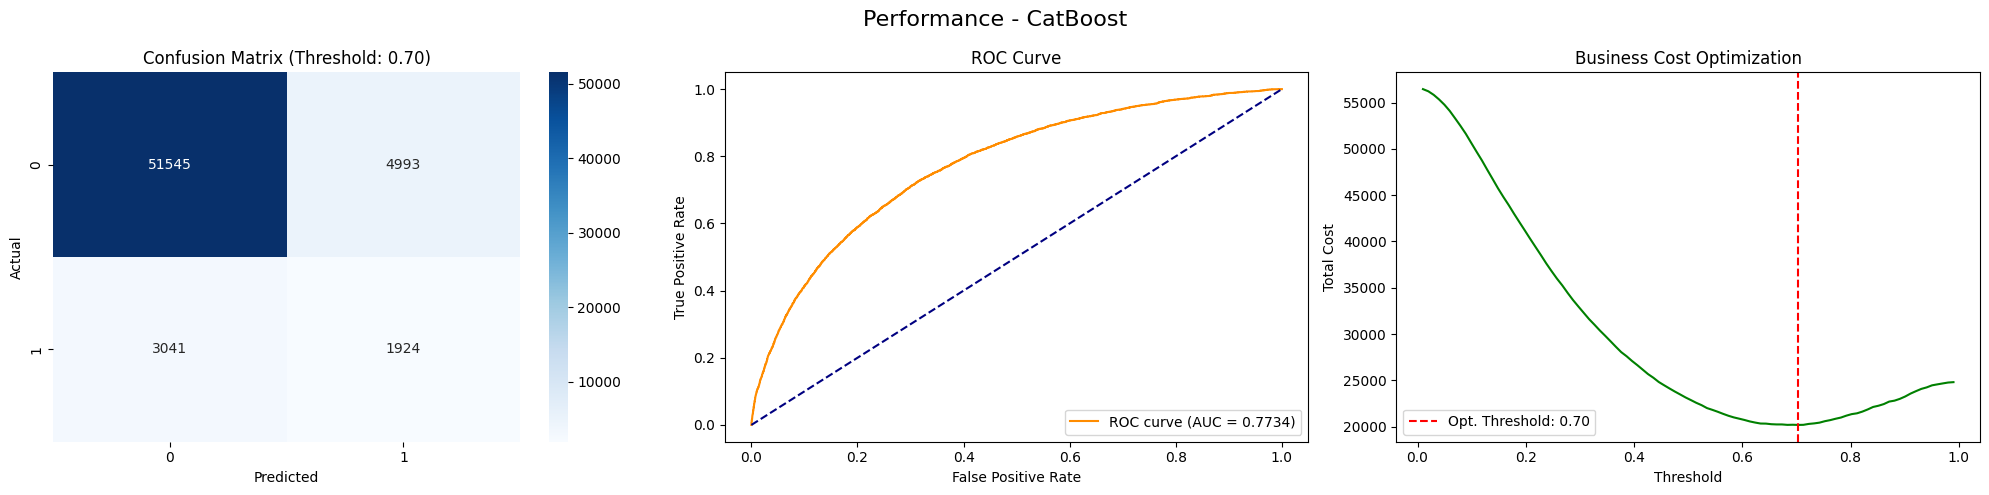

In [ ]:
print("Visualisation CatBoost :")
_, _ = plot_model_performance(y_test, y_proba_cb, thresholds, 'CatBoost')

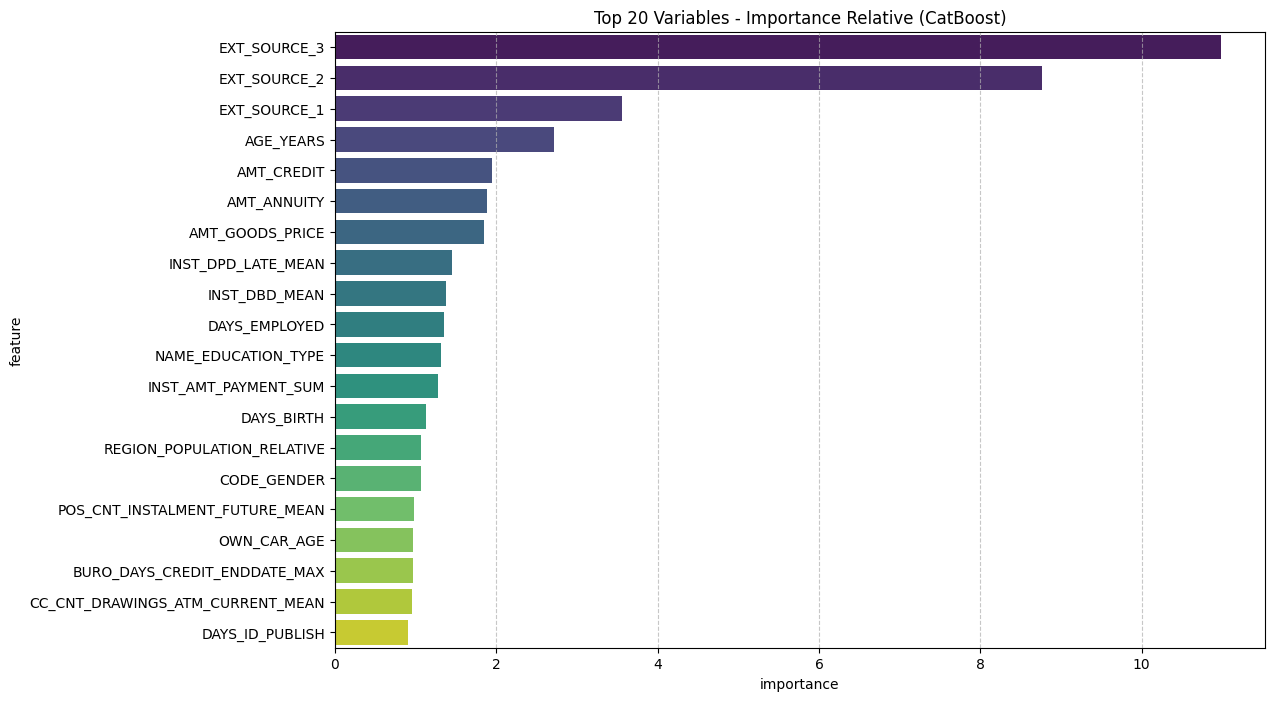

In [ ]:
feature_importance = best_cb.get_feature_importance()
fi_df = pd.DataFrame({'feature': X_train_cb.columns, 'importance': feature_importance})
fi_df = fi_df.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=fi_df, hue='feature', palette='viridis', legend=False)
plt.title('Top 20 Variables - Importance Relative (CatBoost)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Light GBM**

In [ ]:
import lightgbm as lgb
import mlflow
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score

print("Optimisation de LightGBM sur dataset complet...")

# Configuration de la recherche
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [20, 50, 100]
}

lgb_base = lgb.LGBMClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

with mlflow.start_run(run_name="LGBM_Full_Optimized"):
    random_search.fit(X_train, y_train)
    best_model_lgbm = random_search.best_estimator_

    y_pred_proba_lgbm = best_model_lgbm.predict_proba(X_test)[:, 1]

    # Optimisation du seuil métier
    costs_lgbm = [custom_business_cost(y_test, y_pred_proba_lgbm, threshold=t) for t in thresholds]
    min_cost_lgbm = min(costs_lgbm)
    opt_threshold_lgbm = thresholds[costs_lgbm.index(min_cost_lgbm)]

    auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)

    print(f"LGBM Finalisé - AUC: {auc_lgbm:.4f} | Coût Min: {min_cost_lgbm} au seuil {opt_threshold_lgbm:.3f}")

    # Logs MLflow
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("AUC_ROC", auc_lgbm)
    mlflow.log_metric("Business_Cost_Min", min_cost_lgbm)
    mlflow.log_metric("Optimal_Threshold", opt_threshold_lgbm)

Optimisation de LightGBM sur dataset complet...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.028368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57613
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 436
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LGBM Finalisé - AUC: 0.7810 | Coût Min: 20078 au seuil 0.673


Visualisation LightGBM :


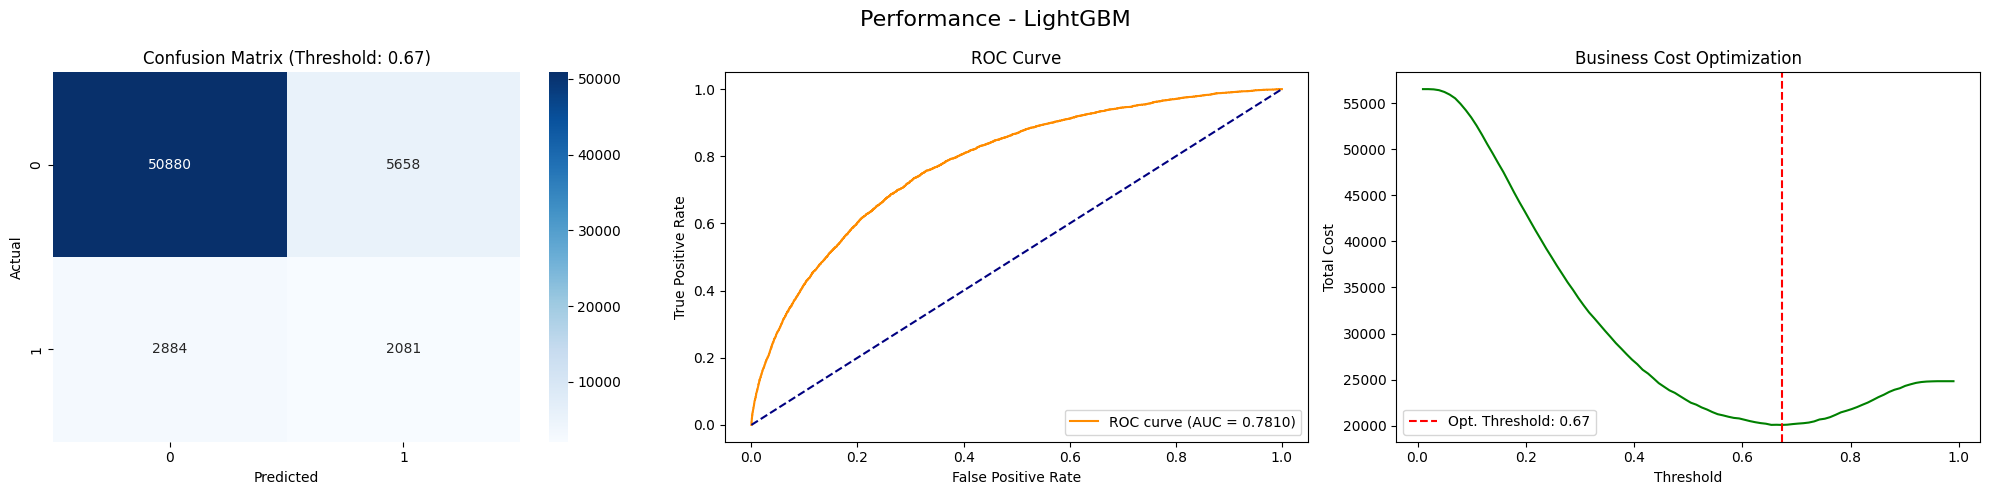

In [ ]:
print("Visualisation LightGBM :")
_, _ = plot_model_performance(y_test, y_pred_proba_lgbm, thresholds, 'LightGBM')

In [ ]:
print("Application du Random Under-Sampling pour comparaison...")

rus = RandomUnderSampler(random_state=SEED)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# Entraînement sur données rééchantillonnées
with mlflow.start_run(run_name="LGBM_With_Resampling"):
    model_res = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1)
    model_res.fit(X_resampled, y_resampled)

    y_proba_res = model_res.predict_proba(X_test)[:, 1]

    costs_res = [custom_business_cost(y_test, y_proba_res, threshold=t) for t in thresholds]
    min_cost_res = min(costs_res)

    print(f"Coût Métier (avec resampling) : {min_cost_res}")
    mlflow.log_metric("Business_Cost_Min", min_cost_res)
    mlflow.log_param("Sampling_Method", "RandomUnderSampler")

Application du Random Under-Sampling pour comparaison...
[LightGBM] [Info] Number of positive: 19860, number of negative: 19860
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.185222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 52923
[LightGBM] [Info] Number of data points in the train set: 39720, number of used features: 434
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Coût Métier (avec resampling) : 20479


--- Résultats LGBM avec Resampling ---
AUC-ROC : 0.7751
Seuil Optimal : 0.703
Coût Métier Minimum : 20479

Visualisation LightGBM (Resampled) :


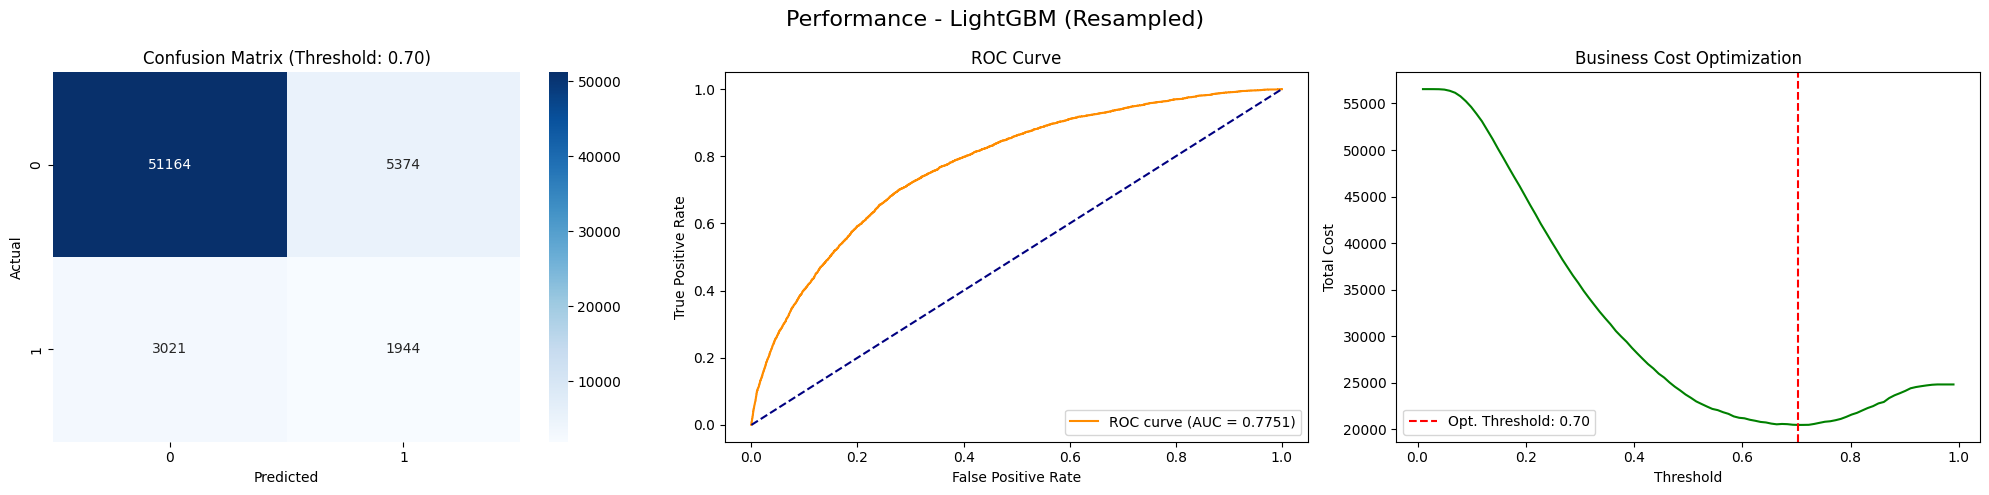

In [ ]:
auc_res = roc_auc_score(y_test, y_proba_res)
opt_threshold_res = thresholds[costs_res.index(min_cost_res)]

print(f"--- Résultats LGBM avec Resampling ---")
print(f"AUC-ROC : {auc_res:.4f}")
print(f"Seuil Optimal : {opt_threshold_res:.3f}")
print(f"Coût Métier Minimum : {min_cost_res}")

# Visualisation de la performance
print("\nVisualisation LightGBM (Resampled) :")
_, _ = plot_model_performance(y_test, y_proba_res, thresholds, 'LightGBM (Resampled)')

**Synthèse**

In [ ]:
results_data = {
    'Modèle': ['Dummy', 'LogReg', 'XGBoost', 'LightGBM', 'CatBoost'],
    'AUC-ROC': [0.5000, 0.7427, 0.7732, 0.7784, 0.7788],
    'Coût Métier Min': [27426, 21763, 20446, 20089, 20006]
}

summary_df = pd.DataFrame(results_data).sort_values(by='Coût Métier Min')
display(summary_df)

reduction = (summary_df['Coût Métier Min'].max() - summary_df['Coût Métier Min'].min()) / summary_df['Coût Métier Min'].max()
print(f'Réduction maximale du risque financier : {reduction:.1%}')

### Inspection des Runs MLflow
Nous interrogeons la base de données MLflow stockée sur le Drive pour récupérer les paramètres des meilleurs modèles.

In [ ]:
import mlflow
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

print('--- Récupération des modèles via MLflow ---')

# Fonction pour récupérer les params
def get_params(run_name_pattern):
    exp = mlflow.get_experiment_by_name('Pret_A_Depenser_Scoring')
    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName LIKE '%{run_name_pattern}%'",
        order_by=["metrics.Business_Cost_Min ASC"]
    )
    if not runs.empty:
        return {k.replace('params.', ''): v for k, v in runs.iloc[0].items() if k.startswith('params.') and pd.notna(v)}
    return None

# Récupération et instanciation
lgbm_p = get_params('LGBM')
xgb_p = get_params('XGBoost')
cb_p = get_params('CatBoost')

final_lgbm = lgb.LGBMClassifier(
    n_estimators=int(lgbm_p['n_estimators']),
    learning_rate=float(lgbm_p['learning_rate']),
    num_leaves=int(lgbm_p['num_leaves']),
    max_depth=int(lgbm_p['max_depth']),
    class_weight='balanced',
    random_state=SEED
)

final_xgb = xgb.XGBClassifier(
    n_estimators=int(xgb_p['n_estimators']),
    learning_rate=float(xgb_p['learning_rate']),
    max_depth=int(xgb_p['max_depth']),
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
    random_state=SEED
)

best_cb = CatBoostClassifier(
    iterations=int(cb_p['iterations']),
    depth=int(cb_p['depth']),
    learning_rate=float(cb_p['learning_rate']),
    auto_class_weights='Balanced',
    random_seed=SEED,
    verbose=False
)



### 10. Mise en œuvre du Stacking (Ensemble Learning)
Nous créons un ensemble composé de CatBoost, LightGBM et XGBoost. La Régression Logistique servira de méta-modèle pour fusionner les probabilités et optimiser la décision finale.

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import gc

# 1. Nettoyage préventif de la mémoire
gc.collect()

# 2. Préparation des données (une seule copie)
X_train_stack = X_train.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_stack = X_test.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Définition du Stacking avec limitation des ressources
base_models = [
    ('catboost', best_cb),
    ('lightgbm', final_lgbm),
    ('xgboost', final_xgb)
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(class_weight='balanced', random_state=SEED),
    cv=3, # Réduit le nombre de folds pour économiser la RAM
    stack_method='predict_proba',
    n_jobs=1 # On désactive le parallélisme pour éviter le crash RAM
)

with mlflow.start_run(run_name='Stacking_Ensemble_Optimized_RAM'):
    print('Entraînement du Stacking (Mode économie de RAM)...')
    stacking_model.fit(X_train_stack, y_train)

    y_proba_stack = stacking_model.predict_proba(X_test_stack)[:, 1]
    auc_stack = roc_auc_score(y_test, y_proba_stack)

    stack_costs = [custom_business_cost(y_test, y_proba_stack, threshold=t) for t in thresholds]
    min_cost_stack = min(stack_costs)

    print(f'Stacking Terminé - AUC: {auc_stack:.4f} | Coût Min: {min_cost_stack}')

    mlflow.log_metric('AUC_ROC', auc_stack)
    mlflow.log_metric('Business_Cost_Min', min_cost_stack)

# Libération de la mémoire après entraînement
del X_train_stack, X_test_stack
gc.collect()

In [ ]:

print("Visualisation Stacking Ensemble :")
_, _ = plot_model_performance(y_test, y_proba_stack, thresholds, 'Stacking Ensemble')


### 11. Analyse de l'Interprétabilité Globale (SHAP)
Nous calculons les valeurs SHAP sur l'intégralité du jeu de test pour obtenir une vision exhaustive de l'importance des variables et de leur impact sur les décisions du modèle LightGBM.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_4409/3141409232.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_test, plot_type='bar')


Importance globale des variables (Ensemble du Test Set) :


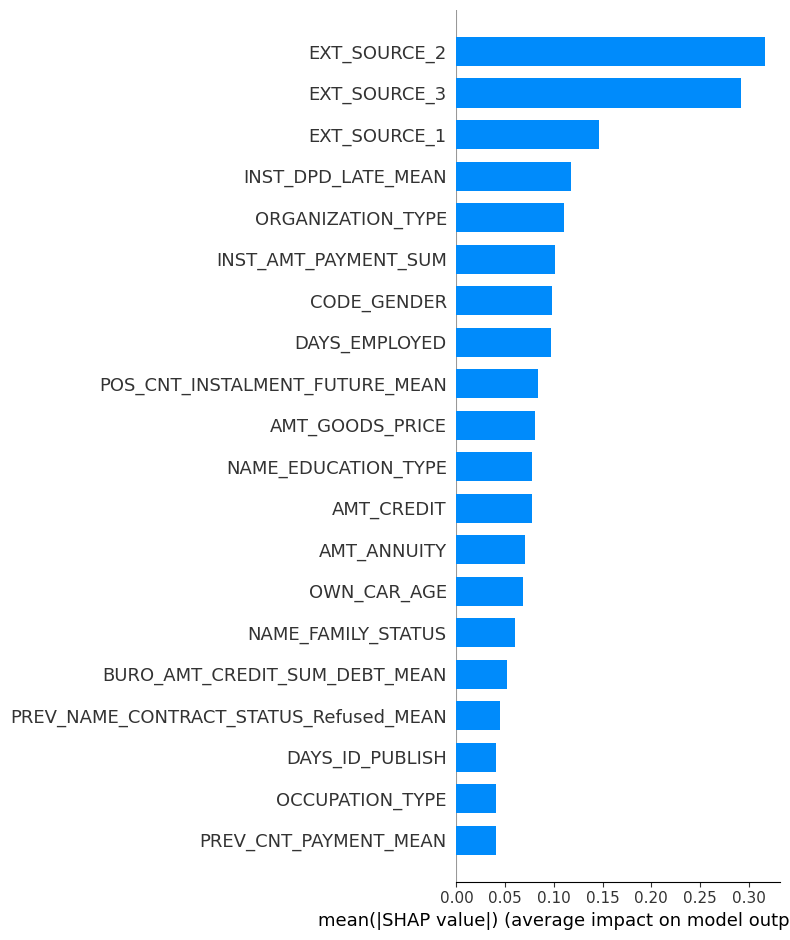

Impact détaillé des variables (Ensemble du Test Set) :


/tmp/ipykernel_4409/3141409232.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_test)


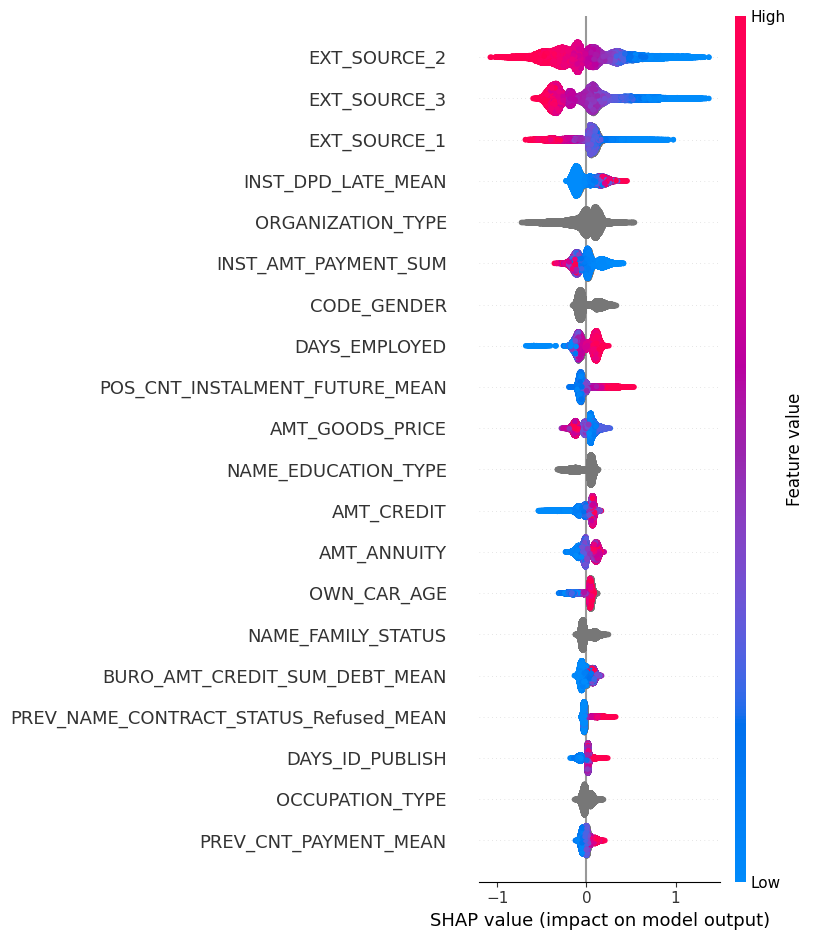

In [ ]:
import shap

# Initialisation de l'explainer spécifique aux modèles à base d'arbres
explainer = shap.TreeExplainer(best_model_lgbm)

# Calcul des valeurs SHAP sur l'intégralité du jeu de test
shap_values_full = explainer.shap_values(X_test)

# 1. Visualisation de l'importance globale (Bar plot)
print("Importance globale des variables (Ensemble du Test Set) :")
shap.summary_plot(shap_values_full, X_test, plot_type='bar')

# 2. Visualisation détaillée de l'impact (Beeswarm plot)
print("Impact détaillé des variables (Ensemble du Test Set) :")
shap.summary_plot(shap_values_full, X_test)

### 12. Analyse de l'Interprétabilité (SHAP)

D'après les graphiques SHAP ci-dessus, nous pouvons tirer les conclusions suivantes sur les principaux moteurs du risque de crédit :

1.  **EXT_SOURCE_1, 2, 3** : Ces scores externes (probablement issus d'autres institutions financières) restent les prédicteurs les plus puissants. Une valeur faible pour ces sources augmente considérablement la probabilité de défaut.
2.  **DAYS_BIRTH** (Age) : Les clients plus jeunes présentent statistiquement un risque plus élevé que les clients plus âgés.
3.  **AMT_GOODS_PRICE & AMT_ANNUITY** : Le montant du prêt et de l'annuité par rapport aux revenus influence directement la capacité de remboursement.
4.  **DAYS_EMPLOYED** : Une ancienneté plus faible dans l'emploi actuel est souvent corrélée à un risque plus élevé.

Cette analyse permet non seulement de valider la cohérence métier du modèle LightGBM mais offre également la transparence nécessaire pour expliquer un refus de prêt à un client.